In [1]:
import plenopticam as pcam
import matplotlib.pyplot as plt
import os
import pickle

Download skipped as illum_test_data.zip already exists


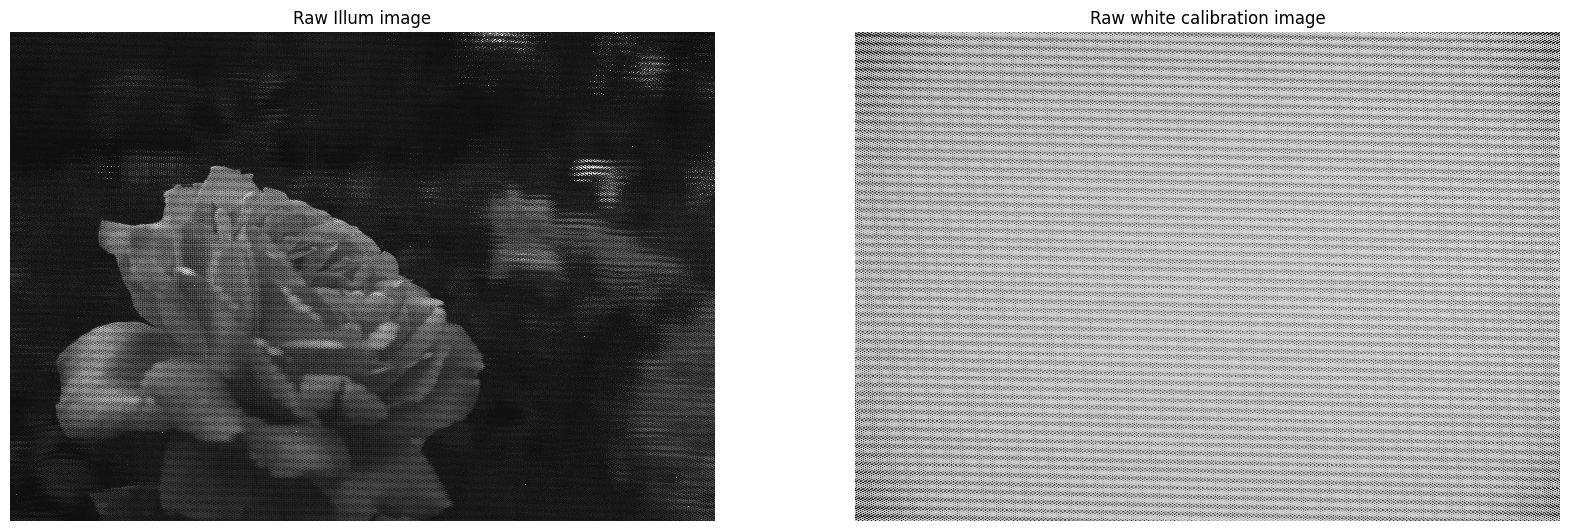

In [2]:

loader = pcam.misc.DataDownloader()
loader.download_data(loader.host_eu_url, fp='./data')
loader.extract_archive(archive_fn='./data/illum_test_data.zip', fname_list='lfr')

# instantiate config object and set image file paths and options
cfg = pcam.cfg.PlenopticamConfig()
cfg.default_values()
cfg.params[cfg.lfp_path] = './data/gradient_rose_close.lfr'
cfg.params[cfg.cal_path] = './data/caldata-B5144402350.tar'
cfg.params[cfg.opt_cali] = True
cfg.params[cfg.ptc_leng] = 13
cfg.params[cfg.cal_meth] = pcam.cfg.constants.CALI_METH[3]

# instantiate status object for progress

sta = pcam.misc.PlenopticamStatus()

reader = pcam.lfp_reader.LfpReader(cfg)
reader.main()
lfp_img = reader.lfp_img

cal_finder = pcam.lfp_calibrator.CaliFinder(cfg)
ret = cal_finder.main()
wht_img = cal_finder.wht_bay

plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.imshow(lfp_img, cmap='gray', interpolation='none')
plt.grid(False)
plt.title('Raw Illum image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(wht_img, cmap='gray', interpolation='none')
plt.grid(False)
plt.title('Raw white calibration image')
plt.axis('off')
plt.show()


In [3]:
# Calibration
cal_obj = pcam.lfp_calibrator.LfpCalibrator(wht_img, cfg, sta)
ret = cal_obj.main()
cfg = cal_obj.cfg


 Debayering
 Progress: Finished 


 Estimate micro image size
 Progress: Finished 


 Compute LoG
 Progress: Finished 


 Select maxima
 Progress: Finished 


 Refine micro image centers
 Progress: Finished 


 Sort micro image centers
 Progress: Finished 


 Grid fitting
 Progress: Finished 


 Save calibration data
 Progress: Finished 



In [4]:
# Alignment
ret = cfg.load_cal_data()
aligner = pcam.lfp_aligner.LfpAligner(lfp_img, cfg, sta, wht_img)
ret = aligner.main()
lfp_img_align = aligner.lfp_img


 Hot pixel detection
 Progress: Finished 


 Estimate white image noise level
 Progress: Finished 


 De-vignetting
 Progress: Finished 


 Debayering
 Progress: Finished 


 Light-field alignment
 Progress: 100%
 Save aligned light-field

 Potential data loss as directory already exists.
 Progress: Finished 



In [5]:
with open(os.path.join(cfg.exp_path, 'lfp_img_align.pkl'), 'rb') as f:
    lfp_img_align = pickle.load(f)

extractor = pcam.lfp_extractor.LfpExtractor(lfp_img_align, cfg, sta)
ret = extractor.main()
vp_img_arr = extractor.vp_img_arr


 Render angular domain
 Progress: Finished 


 Viewpoint composition
 Progress: Finished 


 Color equalization
 Progress: Finished 


 Write viewpoint images
 Progress: Finished 


 Compute depth map
 Progress: Finished 


 Write depth data
 Progress: Finished 



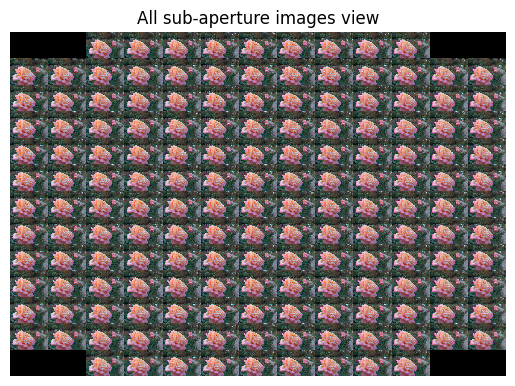

In [6]:
view_obj = pcam.lfp_extractor.LfpViewpoints(vp_img_arr=vp_img_arr)
vp_stack = view_obj.views_stacked_img

plt.figure()
plt.imshow(vp_stack/vp_stack.max(), interpolation='none')
plt.grid(False)
plt.title('All sub-aperture images view')
plt.axis('off')
plt.show()


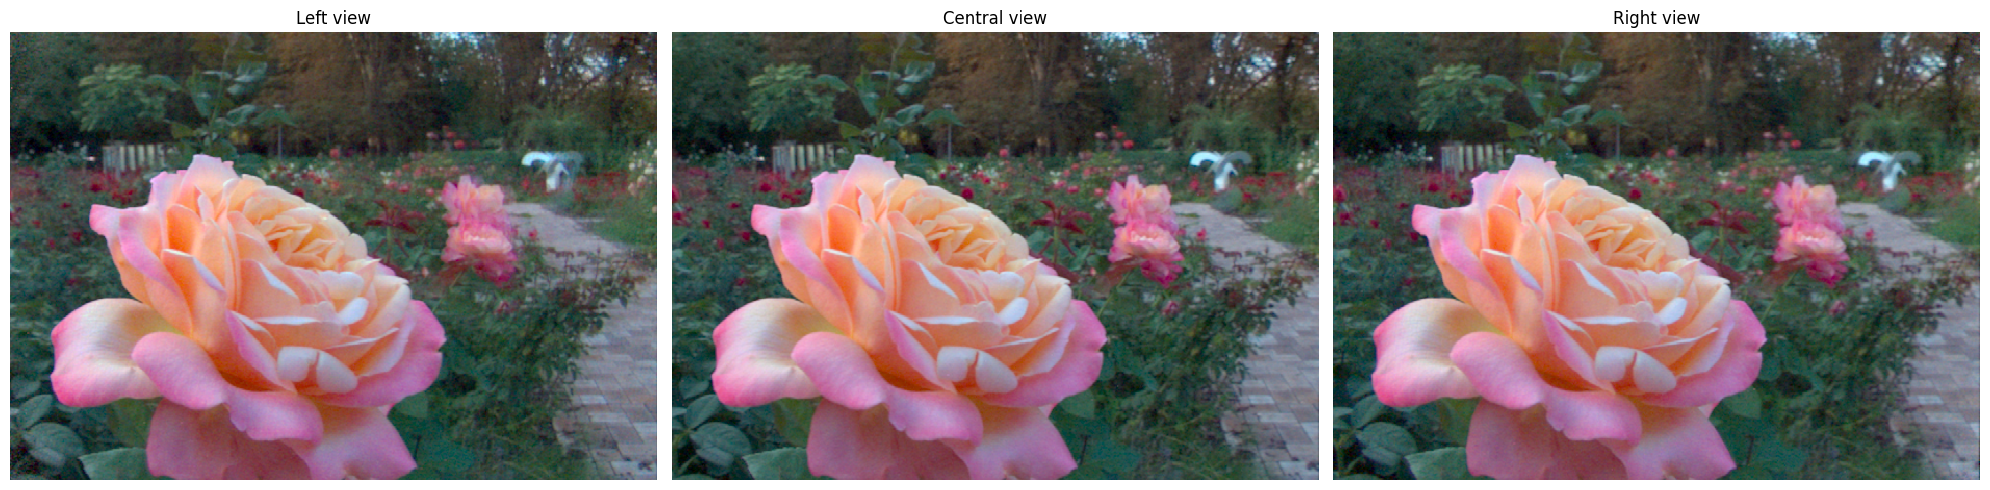

In [7]:
view_obj = pcam.lfp_extractor.LfpViewpoints(vp_img_arr=vp_img_arr)
vp_view = view_obj.central_view

# claim extreme views (left and right) at the center row
left_view  = view_obj.vp_img_arr[:, 0, ...]
right_view = view_obj.vp_img_arr[:, -1, ...]
center_row = view_obj.vp_img_arr.shape[0] // 2
left_view  = view_obj.vp_img_arr[center_row, 0, ...]
right_view = view_obj.vp_img_arr[center_row, -1, ...]


fig, ax = plt.subplots(1, 3, figsize=(20, 10))

ax[0].imshow(left_view/left_view.max(), interpolation='none')
ax[0].set_title("Left view")
ax[0].axis('off')

ax[1].imshow(vp_view/vp_view.max(), interpolation='none')
ax[1].set_title("Central view")
ax[1].axis('off')

ax[2].imshow(right_view/right_view.max(), interpolation='none')
ax[2].set_title("Right view")
ax[2].axis('off')

plt.tight_layout()
plt.show()



 Compute depth map
 Progress: Finished 


 Write depth data
 Progress: Finished 



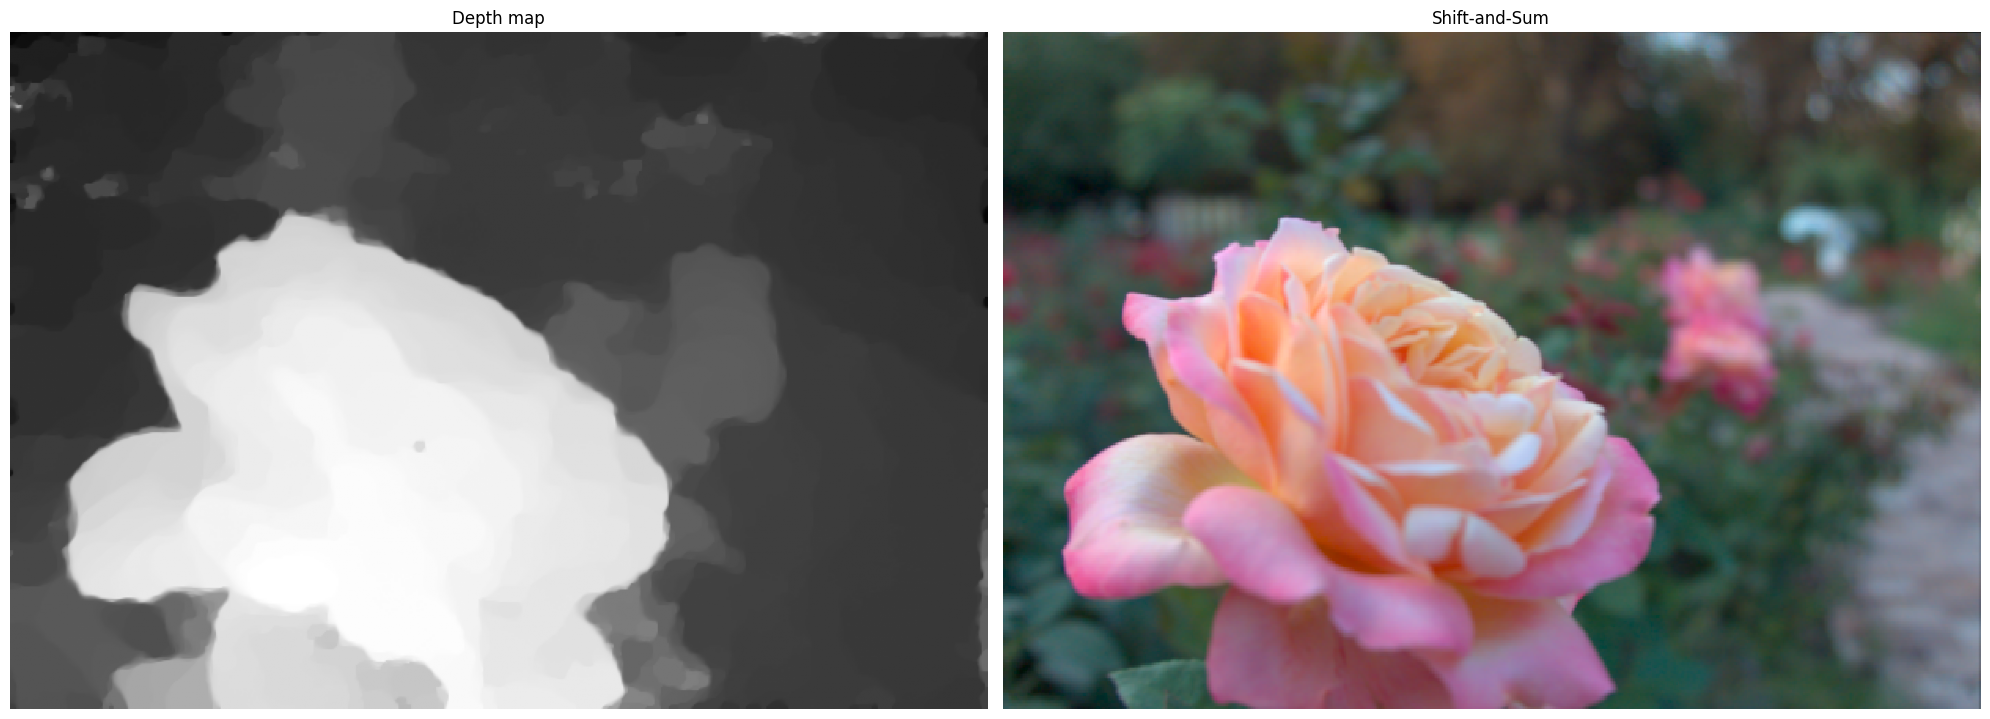

In [8]:

# Depth map estimation
obj = pcam.lfp_extractor.LfpDepth(vp_img_arr=vp_img_arr, cfg=cfg, sta=sta)
obj.main()
depth_map = obj.depth_map


# Shift-and-Sum refocus
cfg.params[cfg.ran_refo] = [-1, 2]
cfg.params[cfg.opt_prnt] = False

refocuser = pcam.lfp_refocuser.LfpRefocuser(
    vp_img_arr=extractor.vp_img_linear,
    cfg=cfg,
    sta=sta
)
refocuser.main()

refo_stack = refocuser.refo_stack

# Taking the 2nd refocus image
refocus_sas = refo_stack[1]


# Plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Depth map
ax[0].imshow(depth_map, cmap='gray')
ax[0].set_title("Depth map")
ax[0].axis('off')
ax[0].grid(False)

# Shift-and-Sum
ax[1].imshow(refocus_sas/refocus_sas.max(), interpolation='none')
ax[1].set_title("Shift-and-Sum")
ax[1].axis('off')
ax[1].grid(False)

plt.tight_layout()
plt.show()

